# Solving ODEs using Python

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import scipy as sp
from scipy.integrate import odeint
from scipy.integrate import solve_ivp

## First order ODEs

Solve differential equation. There are two main solvers in scipy

* `odeint`: Uses a integrator (solver) called lsoda from the FORTRAN library odepack
* `solve_ivp` : More customizable, can choose from a list of possible integrators


### 1. Sky diving problem (involving friction)
There are two forces affecting motion of body: 

$
\vec{F_g} = -m\vec{g} = -m\begin{bmatrix} 0 \\ g \end{bmatrix} \\  
\vec{F_f} = -b|\vec{v}|\vec{v} = -b\sqrt{v_x^2+v_y^2}\begin{bmatrix} v_x \\ v_y \end{bmatrix} \\  
\vec{F} = m \vec{a} = -m\begin{bmatrix} \frac{dv_x}{dt} \\ \frac{dv_y}{dt} \end{bmatrix} = -m\begin{bmatrix} 0 \\ g \end{bmatrix} - b\sqrt{v_x^2+v_y^2}\begin{bmatrix} v_x \\ v_y \end{bmatrix}
$

$$
\frac{dv_x}{dt} = -\frac{b}{m}\sqrt{v_x^2 + v_y^2} \cdot v_x \\  
\frac{dv_y}{dt} = - g -\frac{b}{m}\sqrt{v_x^2 + v_y^2} \cdot v_y \\  
$$
  
  
We define velocity vector (2D plane) $\vec{S}$ as $\vec{S} = (v_x, v_y)$   
where  
$v_x$ is the velocity of body in x-direction  
$v_y$ is the velocity of body in y-direction  
$m$ is mass of body  
$g$ is constant of gravitational acceleration  
$b$ is drag constant which depends upon shape, fluid density, cross-sectional area and velocity

In [4]:
#defining function to pass into odeint
def dSdt(S, t, m, g, b):
    v_x = S[0]
    v_y = S[1]
    return[
        -(b/m)*np.sqrt(v_x**2+v_y**2)*v_x,
        -g-(b/m)*np.sqrt(v_x**2+v_y**2)*v_y
    ]

In [10]:
#input for dSdt
t = np.linspace(0,20,100)
m = 10
g = 9.81
b, vt = m*g/(vt**2), -55 
v0_x, v0_y= 50, 0
y0 = [v0_x, v0_y]

In [11]:
#calling odeint function
sol = odeint(dSdt, y0, t, (m, g, b))

In [13]:
#segregating result in vx and vy
vx = sol.T[0]
vy = sol.T[1]

(0.0, 20.0)

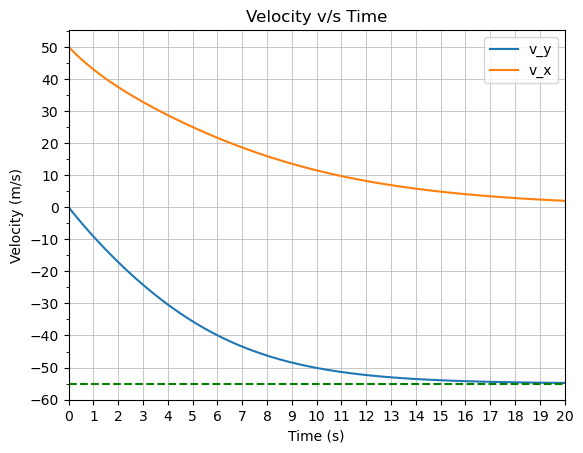

In [50]:
#plotting vx and vy v/s t
plt.plot(t, vy, label="v_y")
plt.plot(t, vx, label="v_x")

plt.axhline(vt, color='g', linestyle='--')

plt.ylabel("Velocity (m/s)")
plt.xlabel("Time (s)")
plt.title("Velocity v/s Time")
plt.legend()

plt.grid(linewidth=0.5)

ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MultipleLocator(10))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(5))
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.xlim(0,20)

How long until one reaches terminal velocity?

In [52]:
test = np.abs(vy - vt)/np.abs(vt) < 0.01
test

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True])

In [57]:
min(t[test])   #answer

17.171717171717173